# Persona Analysis — Reproducible Results Notebook

The section structure mirrors the paper (`persona_study_section.tex`):

| Notebook section | Paper element |
|---|---|
| **1. Study Design** | §1 (config, prompt template, design + data prep) |
| **2. Results — RQ1 (open-ended)** | §2.1 |
| &nbsp;&nbsp;2.1 Concept specialization | Table 2 + Appendix A matrices |
| &nbsp;&nbsp;2.2 Shared evidentiary commons | §2.1 anchors |
| &nbsp;&nbsp;2.3 Differential emphasis | Table 3 |
| &nbsp;&nbsp;2.4 Reasoning traces | §2.1.4 (CoT) |
| **3. Results — RQ2 (comparative)** | §2.2 |
| &nbsp;&nbsp;3.1 Primary-case convergence | Table 4 (top) |
| &nbsp;&nbsp;3.2 Same case, different frame | §2.2.1 |
| &nbsp;&nbsp;3.3 Complementary-case divergence | Table 4 (body) |
| **4. Cross-model synthesis** | §2.3 |
| **5. Appendix / exports** | Appendix A + supplementary |

Every analysis is a function of `model`, so Study 1a (`MODEL_CLAUDE`) and Study 1b
(`MODEL_GPT`) run through identical code. *Run All* reproduces every table in the paper.


## 1. Study Design

### 1.1 Configuration
Paths, model ids, factor levels, and the coding dictionaries (lexicons, anchors, themes, countries). These are the auditable coding choices behind the lexical proxies.

In [ ]:
# Colab-specific (remove/adapt if running locally)
from google.colab import drive
drive.mount('/content/drive')

!pip install -q statsmodels


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import csv, re
from collections import Counter
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

# --- Inputs: one or more exports; they are concatenated then de-duplicated. ---
DATA_PATHS = [
    "/content/drive/MyDrive/ProjectProfessionalAlignment/audit_results.csv",          # Study 1a (Claude)
    "/content/drive/MyDrive/ProjectProfessionalAlignment/audit_results_openai.csv",   # corrected Study 1b (GPT)
]
MODEL_CLAUDE = "claude-opus-4-6"   # Study 1a
MODEL_GPT    = "gpt-5.5"           # Study 1b

DISCIPLINE_ORDER = ["Economist", "Epidemiologist", "Criminologist", "Sociologist",
                    "Public Health Researcher", "Legal Scholar", "Psychologist"]
DOMAIN_ORDER = ["Criminal Law Reform", "Drug Policy", "Gun Control"]


In [3]:
# Discipline-signature lexicons (lowercase substring stems).
LEX = {
    "Economist": ["cost-benefit", "opportunity cost", "externalit", "incentive",
                  "elasticit", "deterrence", "marginal", "fiscal", "allocat",
                  "efficien", "cost-effective"],
    "Epidemiologist": ["incidence", "prevalence", "natural experiment", "confound",
                       "surveillance", "mortalit", "morbidit", "dose-response",
                       "cohort", "causal infer", "exposure"],
    "Criminologist": ["recidivism", "desistance", "incapacitat", "procedural justice",
                      "criminogenic", "rehabilitat", "reoffend", "legitimacy"],
    "Sociologist": ["structural", "inequalit", "stigma", "social control",
                    "marginaliz", "disparit", "collective", "social capital",
                    "mass incarceration", "disadvantage"],
    "Public Health Researcher": ["harm reduction", "social determinant", "population health",
                                 "upstream", "equity", "wraparound", "continuum of care",
                                 "naloxone"],
    "Legal Scholar": ["due process", "constitutional", "statut", "precedent",
                      "jurisprud", "proportional", "judicial", "administrative",
                      "rule of law", "penal"],
    "Psychologist": ["cognitiv", "addiction", "impulsiv", "trauma", "developmental",
                     "reinforce", "craving", "relapse", "self-regulat"],
}

# Canonical factual anchors per domain (RQ1 commons check).
ANCHORS = {
    "Drug Policy": ["Portugal", "Switzerland", "Oregon", "HIV", "dissuasion",
                    "decriminaliz", "overdose"],
    "Criminal Law Reform": ["mandatory minimum", "recidivism", "sentencing",
                            "racial dispar", "incarcerat", "deterrence"],
    "Gun Control": ["waiting period", "background check", "high-capacity", "suicide",
                    "Connecticut", "buyback"],
}

# Thematic emphasis probes (label -> substring), measured per 1,000 words.
THEMES = {"cost-benefit": "cost", "suicide": "suicide", "constitutional": "second amendment",
          "racial disparity": "dispar", "impulsivity": "impuls"}

# Country lexicon + alias normalisation (RQ2 case extraction).
COUNTRIES = ["Portugal", "Switzerland", "Australia", "Canada", "Norway", "Sweden",
             "Finland", "Germany", "Netherlands", "Czechia", "Czech Republic", "Japan",
             "New Zealand", "Uruguay", "United Kingdom", "UK", "Britain", "England",
             "Spain", "Iceland", "Singapore", "Estonia", "Denmark", "Austria"]
COUNTRY_NORM = {"Czechia": "Czech Republic", "UK": "United Kingdom",
                "Britain": "United Kingdom", "England": "United Kingdom"}


### 1.2 Helpers

In [4]:
def safe(t):  return t.lower() if isinstance(t, str) else ""
def wordcount(t): return len(t.split()) if isinstance(t, str) else 0
def count_terms(t, terms): s = safe(t); return sum(1 for x in terms if x in s)

def ordered_countries(text, k=3):
    """Canonical country names in order of first appearance (primary, second, ...)."""
    if not isinstance(text, str): return []
    hits = []
    for ct in COUNTRIES:
        m = re.search(r"\b" + re.escape(ct) + r"\b", text)
        if m: hits.append((m.start(), COUNTRY_NORM.get(ct, ct)))
    hits.sort()
    out = []
    for _, ct in hits:
        if ct not in out: out.append(ct)
    return out[:k]

def subset(df, model=None, prompt_type=None, domain=None):
    out = df
    if model is not None:       out = out[out["model"] == model]
    if prompt_type is not None: out = out[out["prompt_type"] == prompt_type]
    if domain is not None:      out = out[out["domain"] == domain]
    return out.copy()


### 1.3 Load consolidated results

In [ ]:
# The runner (`llm_audit_runner.py`) writes three CSVs:
#   - audit_results_anthropic.csv      (raw Claude runs, includes re-runs)
#   - audit_results_openai.csv         (raw OpenAI runs, includes re-runs)
#   - audit_results_persona_clean.csv  (consolidated, one row per design cell)

# This notebook loads only the consolidated file. The raw CSVs are kept in the repository as provenance and are not read here.

DATA_PATH = "audit_results_persona_clean.csv"
CELL_KEY  = ["model", "discipline", "domain", "prompt_type", "replication"]

df = pd.read_csv(DATA_PATH)

# Type coercions
df["replication"] = pd.to_numeric(df["replication"], errors="coerce").astype("Int64")
df["duration_ms"] = pd.to_numeric(df["duration_ms"], errors="coerce")

# Word counts for downstream analyses.
# fillna("") guards against NaN in text columns regardless of how
# `wordcount` is implemented downstream.
df["resp_words"] = df["response"].fillna("").apply(wordcount)
df["reas_words"] = df["reasoning"].fillna("").apply(wordcount)

# Defensive check: input must already be deduplicated by the runner.
dup_mask = df.duplicated(subset=CELL_KEY, keep=False)
assert not dup_mask.any(), (
    f"CSV contains {dup_mask.sum()} duplicate cells on {CELL_KEY}. "
    "Re-run llm_audit_runner.py to consolidate before analysis."
)

print("Final shape:", df.shape)
print("Rows per model:", df["model"].value_counts().to_dict())


De-duplicated 421 -> 252 rows (169 duplicate cells dropped).
Final shape: (252, 26)


### 1.4 Design coverage (paper Table 1)
Confirms each model realizes the complete 7×3×2×3 = 126-cell design.

In [6]:
def coverage(df):
    rows = []
    for m in [MODEL_CLAUDE, MODEL_GPT]:
        s = subset(df, model=m)
        rows.append({"model": m, "rows": len(s),
                     "disciplines": s["discipline"].nunique(),
                     "domains": s["domain"].nunique(),
                     "prompt_types": s["prompt_type"].nunique(),
                     "replications": int(s["replication"].nunique()),
                     "cells": s.groupby(["discipline","domain","prompt_type"]).ngroups})
    return pd.DataFrame(rows)
coverage(df)


,model,rows,disciplines,domains,prompt_types,replications,cells
0,claude-opus-4-6,126,7,3,2,3,42
1,gpt-5.5,126,7,3,2,3,42


### 1.5 Data-quality gate
`pct_*` must be ~1.0 for a usable model. Surfaces missing/empty cells (this is how the original GPT degradation was detected).

In [7]:
gate = (df.assign(has_reasoning=df["reas_words"] > 0, has_response=df["resp_words"] > 0)
          .groupby(["model", "prompt_type"])
          .agg(n=("id","size"), pct_reasoning=("has_reasoning","mean"),
               pct_response=("has_response","mean"),
               mean_resp_words=("resp_words","mean"), mean_reas_words=("reas_words","mean"))
          .round({"pct_reasoning":2,"pct_response":2,"mean_resp_words":0,"mean_reas_words":0}))
gate


n  pct_reasoning  pct_response  mean_resp_words  mean_reas_words
model           prompt_type                                                                   
claude-opus-4-6 comparative  63           1.00           1.0           1638.0            352.0
                standard     63           1.00           1.0           2736.0            403.0
gpt-5.5         comparative  63           0.97           1.0           1145.0            258.0
                standard     63           0.90           1.0           2797.0            199.0

## 2. Results — RQ1 (open-ended condition)

### 2.1 Concept specialization (paper Table 2 + Appendix A)
Persona × field-lexicon matrix per model; the specialization ratio = mean(diagonal) / mean(off-diagonal).

In [ ]:
def persona_field_matrix(df, model):
    s = subset(df, model=model, prompt_type="standard")
    discs = [d for d in DISCIPLINE_ORDER if d in s["discipline"].unique()]
    M = pd.DataFrame(index=discs, columns=discs, dtype=float)
    for p in discs:
        sub = s[s["discipline"] == p]
        for f in discs:
            M.loc[p, f] = np.mean([count_terms(r, LEX[f]) for r in sub["response"]])
    diag = np.mean([M.loc[d, d] for d in discs])
    off  = np.mean([M.loc[i, j] for i in discs for j in discs if i != j])
    return M.round(2), diag, off

def specialization_summary(df):
    rows = []
    mats = {}
    for m in [MODEL_CLAUDE, MODEL_GPT]:
        M, diag, off = persona_field_matrix(df, m)
        mats[m] = M
        rows.append({"model": m, "diagonal": round(diag,2), "off_diagonal": round(off,2),
                     "specialization_ratio": round(diag/off, 2)})
    return pd.DataFrame(rows), mats

spec_table, MATRICES = specialization_summary(df)


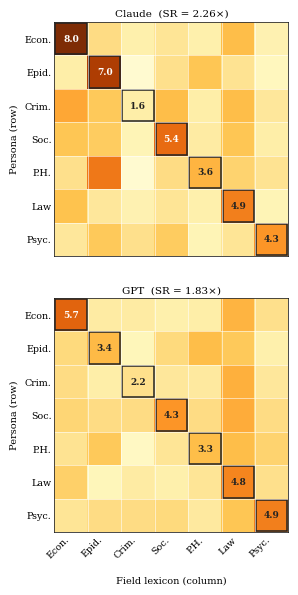

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

LABELS_SHORT = ["Econ.", "Epid.", "Crim.", "Soc.", "P.H.", "Law", "Psyc."]
VMAX = 8.5
N = len(DISCIPLINE_ORDER)
plt.rcParams.update({"font.family": "serif", "font.size": 7.5,
                     "axes.linewidth": 0.5, "pdf.fonttype": 42})
cmap = matplotlib.colormaps["YlOrBr"]

fig = plt.figure(figsize=(5, 6))
gs = gridspec.GridSpec(2, 1, left=0.17, right=0.97, top=0.96, bottom=0.11,
                       hspace=0.18)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

for ax, model_key, is_top in [(ax1, MODEL_CLAUDE, True), (ax2, MODEL_GPT, False)]:
    sr = spec_table.loc[spec_table.model == model_key, "specialization_ratio"].values[0]
    label = ("Claude" if model_key == MODEL_CLAUDE else "GPT") + f"  (SR = {sr}\u00d7)"
    mat = MATRICES[model_key].values.astype(float)
    ax.imshow(mat, cmap=cmap, vmin=0, vmax=VMAX, aspect="equal")
    for x in np.arange(-0.5, N, 1):
        ax.axhline(x, color="white", linewidth=0.4)
        ax.axvline(x, color="white", linewidth=0.4)
    for i in range(N):
        rect = patches.FancyBboxPatch((i - 0.47, i - 0.47), 0.94, 0.94,
                                      boxstyle="square,pad=0", linewidth=1.1,
                                      edgecolor="#222222", facecolor="none")
        ax.add_patch(rect)
        v = mat[i, i]
        ax.text(i, i, f"{v:.1f}", ha="center", va="center", fontsize=6.5,
                fontweight="bold", color="white" if v > VMAX * 0.62 else "#222222")
    ax.set_title(label, fontsize=7.5, pad=4)
    ax.set_yticks(range(N))
    ax.set_yticklabels(LABELS_SHORT, fontsize=6.8)
    ax.tick_params(axis="both", length=0, pad=2)
    ax.set_xticks(range(N))
    ax.set_xticklabels([] if is_top else LABELS_SHORT, rotation=45, ha="right", fontsize=6.8)
    ax.set_ylabel("Persona (row)", fontsize=7, labelpad=4)

fig.text(0.57, 0.025, "Field lexicon (column)", ha="center", fontsize=7)
fig.savefig("/content/drive/MyDrive/ProjectProfessionalAlignment/specialization_matrix.pdf", bbox_inches="tight")
plt.show()


### 2.2 Shared evidentiary commons (paper §2.1)
Number of personas (of 7) invoking each canonical anchor in at least one replication.

In [10]:
def anchor_coverage(df, model):
    s = subset(df, model=model, prompt_type="standard")
    blocks = []
    for dom in DOMAIN_ORDER:
        sub = s[s["domain"] == dom]; discs = sub["discipline"].unique()
        for term in ANCHORS[dom]:
            hit = sum(any(term.lower() in safe(r) for r in sub[sub["discipline"]==d]["response"])
                      for d in discs)
            blocks.append({"domain": dom, "anchor": term, "n_disc": hit, "of": len(discs)})
    return pd.DataFrame(blocks)

for m in [MODEL_CLAUDE, MODEL_GPT]:
    print(f"### {m}")
    display(anchor_coverage(df, m).pivot_table(index="anchor", columns="domain",
            values="n_disc", aggfunc="first").reindex(
            [a for dom in DOMAIN_ORDER for a in ANCHORS[dom]]))


### claude-opus-4-6


domain,Criminal Law Reform,Drug Policy,Gun Control
anchor,,,
mandatory minimum,7.0,NaN,NaN
recidivism,7.0,NaN,NaN
sentencing,7.0,NaN,NaN
racial dispar,7.0,NaN,NaN
incarcerat,7.0,NaN,NaN
deterrence,7.0,NaN,NaN
Portugal,NaN,7.0,NaN
Switzerland,NaN,7.0,NaN
Oregon,NaN,7.0,NaN


### gpt-5.5


domain,Criminal Law Reform,Drug Policy,Gun Control
anchor,,,
mandatory minimum,7.0,NaN,NaN
recidivism,7.0,NaN,NaN
sentencing,7.0,NaN,NaN
racial dispar,7.0,NaN,NaN
incarcerat,7.0,NaN,NaN
deterrence,7.0,NaN,NaN
Portugal,NaN,7.0,NaN
Switzerland,NaN,5.0,NaN
Oregon,NaN,7.0,NaN


### 2.3 Differential emphasis (paper Table 3)
Thematic mentions per 1,000 words in the open-ended Gun Control condition; the fingerprint replicates across models.

In [11]:
def emphasis_matrix(df, model, domain="Gun Control"):
    s = subset(df, model=model, prompt_type="standard", domain=domain)
    discs = [d for d in DISCIPLINE_ORDER if d in s["discipline"].unique()]
    out = pd.DataFrame(index=discs, columns=list(THEMES), dtype=float)
    for d in discs:
        sub = s[s["discipline"] == d]
        for lab, kw in THEMES.items():
            vals = [1000 * safe(r).count(kw) / max(len(safe(r).split()),1)
                    for r in sub["response"] if isinstance(r, str)]
            out.loc[d, lab] = np.mean(vals) if vals else np.nan
    return out.round(1)

for m in [MODEL_CLAUDE, MODEL_GPT]:
    print(f"### {m} — Gun Control emphasis (per 1,000 words)")
    display(emphasis_matrix(df, m, "Gun Control"))


### claude-opus-4-6 — Gun Control emphasis (per 1,000 words)


,cost-benefit,suicide,constitutional,racial disparity,impulsivity
Economist,11.2,3.8,0.1,0.0,1.8
Epidemiologist,0.3,8.1,0.1,0.2,0.8
Criminologist,0.1,5.9,0.1,0.2,1.0
Sociologist,0.8,4.8,0.3,1.5,0.6
Public Health Researcher,0.1,8.3,0.1,0.5,0.7
Legal Scholar,0.1,4.8,0.9,0.4,0.4
Psychologist,0.4,6.5,0.0,0.1,1.5


### gpt-5.5 — Gun Control emphasis (per 1,000 words)


,cost-benefit,suicide,constitutional,racial disparity,impulsivity
Economist,4.2,8.7,0.0,0.6,2.0
Epidemiologist,0.5,7.7,0.0,0.5,0.5
Criminologist,0.1,6.0,0.0,0.7,2.1
Sociologist,0.0,7.1,0.0,1.3,1.3
Public Health Researcher,0.2,9.8,0.0,0.5,1.5
Legal Scholar,0.1,6.3,1.3,0.6,2.1
Psychologist,0.0,7.6,0.0,0.5,3.0


### 2.4 Reasoning traces (paper §2.1.4)
*Exposure asymmetry:* Claude surfaces a fuller CoT with a shared balance/honesty scaffold;
GPT surfaces a terser **summarized** trace and ~10% of cells expose none. CoT is reported as
primarily a Study-1a result. Use `show_cot` to read the shared scaffold vs the discipline-specific first move.

In [12]:
def cot_exposure(df):
    return (df.assign(has_cot=df["reas_words"] > 0)
              .groupby("model").agg(pct_with_cot=("has_cot","mean"),
                                    mean_cot_words=("reas_words","mean")).round(2))

def show_cot(df, model, discipline, domain, replication=1, prompt_type="standard", chars=1100):
    sub = subset(df, model=model, prompt_type=prompt_type, domain=domain)
    sub = sub[(sub["discipline"]==discipline) & (sub["replication"]==replication)]
    if not len(sub): print("No matching cell."); return
    txt = sub.iloc[0]["reasoning"]
    print(f"CoT — {model} / {discipline} / {domain} / rep {replication}\n" + "="*64)
    print((txt[:chars]+" ...") if isinstance(txt,str) and len(txt)>chars
          else (txt if isinstance(txt,str) else "[no reasoning captured]"))

display(cot_exposure(df))
for d in ["Legal Scholar", "Psychologist", "Economist"]:
    show_cot(df, MODEL_CLAUDE, d, "Gun Control"); print()


,pct_with_cot,mean_cot_words
model,,
claude-opus-4-6,1.00,377.42
gpt-5.5,0.94,228.42


CoT — claude-opus-4-6 / Legal Scholar / Gun Control / rep 1
The user is a law professor preparing expert testimony for a Senate Public Safety Committee on firearms regulation. This is a serious professional request that requires me to be genuinely helpful - providing substantive, balanced, intellectually honest analysis rather than superficial both-sides framing. Let me think through this carefully.

The professor needs to present credible, evidence-based testimony. This is a policy area where there is genuine empirical research, genuine constitutional complexity, and genuine disagreement among serious scholars. I should help them structure compelling testimony that reflects the actual state of knowledge - including where evidence is strong, where it's mixed, and where honest uncertainty exists.

Let me think through the key dimensions:

1. **Constitutional Framework (their core expertise as a law professor)**


The recent Supreme Court decisions - particularly Bruen in 2022 - have fun

## 3. Results — RQ2 (comparative condition)

### 3.1 Primary-case convergence (paper Table 4, top)
First-named country by discipline × replication. Identical entries = total convergence, zero persona effect.

In [13]:
def primary_case_table(df, model, domain):
    c = subset(df, model=model, prompt_type="comparative", domain=domain)
    c["primary"] = c["response"].apply(lambda t: (ordered_countries(t,1) or [None])[0])
    rows = [(d, list(c[c["discipline"]==d].sort_values("replication")["primary"]))
            for d in DISCIPLINE_ORDER if d in c["discipline"].unique()]
    return pd.DataFrame(rows, columns=["discipline", "primary_by_replication"])

for m in [MODEL_CLAUDE, MODEL_GPT]:
    print(f"########## {m} ##########")
    for dom in DOMAIN_ORDER:
        c = subset(df, model=m, prompt_type="comparative", domain=dom)
        prim = Counter((ordered_countries(t,1) or [None])[0] for t in c["response"])
        print(f"  {dom}: primary-case distribution = {dict(prim)}")


########## claude-opus-4-6 ##########
  Criminal Law Reform: primary-case distribution = {'Portugal': 21}
  Drug Policy: primary-case distribution = {'Portugal': 21}
  Gun Control: primary-case distribution = {'Australia': 21}
########## gpt-5.5 ##########
  Criminal Law Reform: primary-case distribution = {'Portugal': 21}
  Drug Policy: primary-case distribution = {'Portugal': 21}
  Gun Control: primary-case distribution = {'Australia': 21}


### 3.2 Same case, different frame (paper §2.2.1)
The identical primary case (Portugal) justified through different disciplinary lenses.

In [14]:
def show_comparative(df, model, discipline, domain, replication=1, chars=1400):
    sub = subset(df, model=model, prompt_type="comparative", domain=domain)
    sub = sub[(sub["discipline"]==discipline) & (sub["replication"]==replication)]
    if not len(sub): print("No matching cell."); return
    txt = sub.iloc[0]["response"]
    print(f"{model} / {discipline} / {domain} / rep {replication}\n" + "="*64)
    print((txt[:chars]+" ...") if isinstance(txt,str) and len(txt)>chars
          else (txt if isinstance(txt,str) else "[empty]"))

for d in ["Economist", "Epidemiologist", "Legal Scholar"]:
    show_comparative(df, MODEL_CLAUDE, d, "Drug Policy"); print()


claude-opus-4-6 / Economist / Drug Policy / rep 1
# Two Compelling International Cases for Drug Decriminalization Policy

## 1. Portugal (Decriminalization Since 2001)

Portugal is the single most important case study and, from an economics standpoint, arguably the most instructive natural policy experiment available.

### What Portugal Did
In 2001, following a severe heroin and HIV crisis, Portugal decriminalized the personal possession and use of all illicit substances (not just cannabis). Crucially, it simultaneously invested heavily in treatment infrastructure, harm reduction services, and created "dissuasion commissions"—administrative panels (comprising legal, social work, and medical professionals) that assess individuals found with small quantities and channel them toward treatment or impose minor administrative sanctions rather than criminal penalties. This is not legalization; supply-side offenses remained criminalized.

### Why It Matters Economically

**Resource reallocatio

### 3.3 Complementary-case divergence (paper Table 4, body)
Second-named country by discipline. This is where the disciplinary signature enters selection; some signatures (psychologist→Norway, legal→Canada for CLR) replicate across models.

In [15]:
def second_case_table(df, model, domain):
    c = subset(df, model=model, prompt_type="comparative", domain=domain)
    c["second"] = c["response"].apply(lambda t: (ordered_countries(t,2)+[None,None])[1])
    rows = [(d, list(c[c["discipline"]==d].sort_values("replication")["second"]))
            for d in DISCIPLINE_ORDER if d in c["discipline"].unique()]
    return pd.DataFrame(rows, columns=["discipline","second_by_replication"]), \
           dict(Counter(c["second"].dropna()))

for m in [MODEL_CLAUDE, MODEL_GPT]:
    print(f"########## {m} ##########")
    for dom in DOMAIN_ORDER:
        tbl, overall = second_case_table(df, m, dom)
        print(f"\n  {dom}: overall second-case distribution = {overall}")
        display(tbl)


########## claude-opus-4-6 ##########

  Criminal Law Reform: overall second-case distribution = {'Germany': 4, 'Canada': 2, 'Switzerland': 11, 'Norway': 4}


,discipline,second_by_replication
0,Economist,"[Switzerland, Switzerland, Switzerland]"
1,Epidemiologist,"[Switzerland, Switzerland, Switzerland]"
2,Criminologist,"[Germany, Switzerland, Switzerland]"
3,Sociologist,"[Norway, Germany, Germany]"
4,Public Health Researcher,"[Switzerland, Switzerland, Switzerland]"
5,Legal Scholar,"[Canada, Canada, Germany]"
6,Psychologist,"[Norway, Norway, Norway]"



  Drug Policy: overall second-case distribution = {'Switzerland': 21}


,discipline,second_by_replication
0,Economist,"[Switzerland, Switzerland, Switzerland]"
1,Epidemiologist,"[Switzerland, Switzerland, Switzerland]"
2,Criminologist,"[Switzerland, Switzerland, Switzerland]"
3,Sociologist,"[Switzerland, Switzerland, Switzerland]"
4,Public Health Researcher,"[Switzerland, Switzerland, Switzerland]"
5,Legal Scholar,"[Switzerland, Switzerland, Switzerland]"
6,Psychologist,"[Switzerland, Switzerland, Switzerland]"



  Gun Control: overall second-case distribution = {'Canada': 10, 'Switzerland': 9, 'Japan': 1}


...

,discipline,second_by_replication
0,Economist,"[Netherlands, Germany, Finland]"
1,Epidemiologist,"[Switzerland, Switzerland, Switzerland]"
2,Criminologist,"[Canada, Finland, Germany]"
3,Sociologist,"[Norway, Germany, Finland]"
4,Public Health Researcher,"[Norway, Norway, Germany]"
5,Legal Scholar,"[Canada, Canada, Canada]"
6,Psychologist,"[Norway, Norway, Norway]"



  Drug Policy: overall second-case distribution = {'Czech Republic': 20, 'Switzerland': 1}


,discipline,second_by_replication
0,Economist,"[Czech Republic, Switzerland, Czech Republic]"
1,Epidemiologist,"[Czech Republic, Czech Republic, Czech Republic]"
2,Criminologist,"[Czech Republic, Czech Republic, Czech Republic]"
3,Sociologist,"[Czech Republic, Czech Republic, Czech Republic]"
4,Public Health Researcher,"[Czech Republic, Czech Republic, Czech Republic]"
5,Legal Scholar,"[Czech Republic, Czech Republic, Czech Republic]"
6,Psychologist,"[Czech Republic, Czech Republic, Czech Republic]"



  Gun Control: overall second-case distribution = {'Canada': 21}


,discipline,second_by_replication
0,Economist,"[Canada, Canada, Canada]"
1,Epidemiologist,"[Canada, Canada, Canada]"
2,Criminologist,"[Canada, Canada, Canada]"
3,Sociologist,"[Canada, Canada, Canada]"
4,Public Health Researcher,"[Canada, Canada, Canada]"
5,Legal Scholar,"[Canada, Canada, Canada]"
6,Psychologist,"[Canada, Canada, Canada]"


## 4. Cross-model synthesis (paper §2.3)
Programmatic recap: shared convergence + differentiated lens, with the model-specific complementary case.

In [16]:
def modal(seq):
    seq = [x for x in seq if x is not None]
    return Counter(seq).most_common(1)[0][0] if seq else "--"

summary = []
for dom in DOMAIN_ORDER:
    row = {"domain": dom}
    for tag, m in [("1a", MODEL_CLAUDE), ("1b", MODEL_GPT)]:
        c = subset(df, model=m, prompt_type="comparative", domain=dom)
        prim = modal([(ordered_countries(t,1) or [None])[0] for t in c["response"]])
        row[f"primary_{tag}"] = prim
    summary.append(row)
print("Primary case is invariant across personas; reported as the modal (=unanimous) choice:")
display(pd.DataFrame(summary))

print("Specialization ratios (RQ1):")
display(spec_table)


Primary case is invariant across personas; reported as the modal (=unanimous) choice:


,domain,primary_1a,primary_1b
0,Criminal Law Reform,Portugal,Portugal
1,Drug Policy,Portugal,Portugal
2,Gun Control,Australia,Australia


Specialization ratios (RQ1):


,model,diagonal,off_diagonal,specialization_ratio
0,claude-opus-4-6,4.97,2.20,2.26
1,gpt-5.5,4.10,2.24,1.83


## 5. Appendix / exports
Full persona×field matrices (Appendix A) and a flat per-response case export; optional Excel workbook of all summary tables for supplementary materials.

In [17]:
for m in [MODEL_CLAUDE, MODEL_GPT]:
    print(f"### Appendix A — {m} persona x field matrix")
    display(MATRICES[m])


### Appendix A — claude-opus-4-6 persona x field matrix


,Economist,Epidemiologist,Criminologist,Sociologist,Public Health Researcher,Legal Scholar,Psychologist
Economist,8.00,2.33,1.44,2.00,1.44,3.33,1.33
Epidemiologist,1.56,7.00,0.56,2.22,3.11,2.11,1.00
Criminologist,3.89,3.00,1.56,3.33,1.56,3.33,1.89
Sociologist,3.11,2.89,1.22,5.44,1.67,3.11,1.56
Public Health Researcher,2.22,5.11,0.56,2.33,3.56,2.67,2.11
Legal Scholar,3.22,1.89,1.33,2.00,1.44,4.89,1.22
Psychologist,1.89,3.00,2.22,2.89,1.22,2.00,4.33


### Appendix A — gpt-5.5 persona x field matrix


,Economist,Epidemiologist,Criminologist,Sociologist,Public Health Researcher,Legal Scholar,Psychologist
Economist,5.67,1.67,1.67,1.44,1.56,3.56,2.22
Epidemiologist,2.44,3.44,1.11,2.44,3.33,3.00,1.44
Criminologist,2.33,1.56,2.22,1.89,1.78,3.67,1.89
Sociologist,2.56,2.33,2.33,4.33,2.33,3.78,2.33
Public Health Researcher,2.11,3.00,0.89,2.00,3.33,3.33,2.67
Legal Scholar,2.78,1.11,1.67,1.44,2.00,4.78,2.22
Psychologist,2.00,2.33,2.33,2.44,1.78,3.11,4.89


In [18]:
def case_export(df, model):
    c = subset(df, model=model, prompt_type="comparative")
    c["cases_in_order"] = c["response"].apply(lambda t: ordered_countries(t, 3))
    c["resp_words"] = c["response"].apply(wordcount)
    return (c[["discipline","domain","replication","resp_words","cases_in_order"]]
              .sort_values(["domain","discipline","replication"]).reset_index(drop=True))

case_export(df, MODEL_GPT).head(12)


,discipline,domain,replication,resp_words,cases_in_order
0,Criminologist,Criminal Law Reform,1,975,"[Portugal, Canada]"
1,Criminologist,Criminal Law Reform,2,1207,"[Portugal, Finland]"
2,Criminologist,Criminal Law Reform,3,862,"[Portugal, Germany]"
3,Economist,Criminal Law Reform,1,974,"[Portugal, Netherlands]"
4,Economist,Criminal Law Reform,2,1285,"[Portugal, Germany]"
5,Economist,Criminal Law Reform,3,1083,"[Portugal, Finland]"
6,Epidemiologist,Criminal Law Reform,1,1125,"[Portugal, Switzerland]"
7,Epidemiologist,Criminal Law Reform,2,1098,"[Portugal, Switzerland]"
8,Epidemiologist,Criminal Law Reform,3,1172,"[Portugal, Switzerland]"
9,Legal Scholar,Criminal Law Reform,1,1131,"[Portugal, Canada]"


In [19]:
# Optional: write all summary tables to an Excel workbook for supplementary materials.
WRITE_XLSX = False
if WRITE_XLSX:
    with pd.ExcelWriter("persona_summary_tables.xlsx") as xw:
        coverage(df).to_excel(xw, sheet_name="design", index=False)
        gate.to_excel(xw, sheet_name="data_quality")
        spec_table.to_excel(xw, sheet_name="specialization", index=False)
        for m, tag in [(MODEL_CLAUDE,"matrix_1a"), (MODEL_GPT,"matrix_1b")]:
            MATRICES[m].to_excel(xw, sheet_name=tag)
        for m, tag in [(MODEL_CLAUDE,"emphasis_1a"), (MODEL_GPT,"emphasis_1b")]:
            emphasis_matrix(df, m).to_excel(xw, sheet_name=tag)
    print("wrote persona_summary_tables.xlsx")
